All spectral flux values should be in units of erg/s/ang/cm^2, and wavelengths should be those of the rest frame.

# 2020jfo

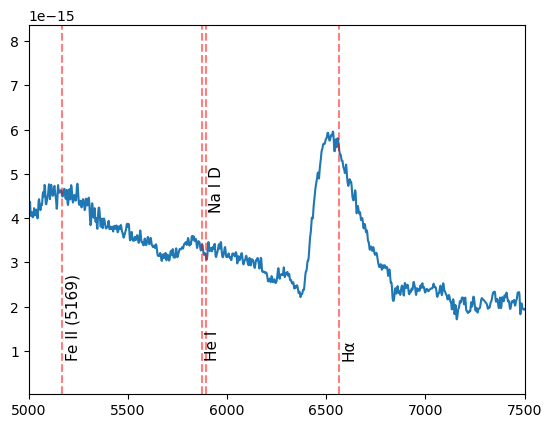

In [ ]:
# spectra MJD = 58988
# VARLIST:  MJD        FLT  FLUXCAL   FLUXCALERR    MAG     MAGERR     MAGSYS   TELESCOPE    INSTRUMENT   DQ
# OBS:      58986.256  r-ZTF  151722.942  4208.276  14.547  0.030  None  P48  ZTF-Cam  None
# flux in erg/s/ang/cm^2, lum in erg/s/ang, F = (1/k)L, k = 4*pi*d^2

# Get observed data and deredshift
from scipy.interpolate import interp1d
import emulator.interpolator.util as util
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd
import numpy as np
z = 0.005224
df = pd.read_csv('2020jfo-FLOYDS-S-2020-05-19.csv', comment='#')
wav = df['wavelength'] / (1 + z)
flux = df['flux']
flux_err = df['fluxerr']

# Flux calibrate using filter transmission, and the filter flux density
from astropy.constants import c
filter_df = pd.read_csv('Palomar_ZTF.r_fil.dat', names=['wavelength', 'transmission'], sep=' ')
transmission = interp1d(filter_df['wavelength'], filter_df['transmission'], bounds_error=False)(wav)
m_AB = 14.547
f_0 = 2.64009e-9 * u.erg/u.s/u.AA/u.cm**2
f_density = 10**(m_AB/-2.5) * f_0
mask = np.isfinite(transmission)
calib_factor = np.sum(f_density.value*transmission[mask]) / np.sum(flux[mask])
flux *= calib_factor
flux_err *= calib_factor

# Write the new calibrated data
new = pd.DataFrame({'wavelength': wav, 'flux': flux, 'fluxerr': flux_err})
new.to_csv('2020jfo-2020-05-19.csv', index=False)

plt.plot(wav, flux)
plt.xlim(5000, 7500)
util.label_common_features()
plt.show()

In [5]:
# Deredshift other flux calibrated spectra
import pandas as pd

# 2020jww
z = 0.0457
df = pd.read_csv('2020jww-KAST-2020-05-23_calibrated.flm', names=['wavelength', 'flux'], sep=' ', index_col=False)
wav = df['wavelength']
flux = df['flux']
wav /= (1 + z)
new = pd.DataFrame({'wavelength': wav, 'flux': flux})
new.to_csv('2020jww-2020-05-23.csv', index=False)
t_exp = 58992 - 58982
print(t_exp)

# 2020hgw
z = 0.0432
df = pd.read_csv('2020hgw-KAST-2020-05-23_calibrated.flm', names=['wavelength', 'flux'], sep=' ', index_col=False)
wav = df['wavelength']
flux = df['flux']
wav /= (1 + z)
new = pd.DataFrame({'wavelength': wav, 'flux': flux})
new.to_csv('2020hgw-2020-05-23.csv', index=False)
t_exp = 58992 - 58950
print(t_exp)

# 2020rth
z = 0.0184
df = pd.read_csv('2020rth-RSS-2020-08-24_calibrated.flm', names=['wavelength', 'flux'], sep=' ', index_col=False)
wav = df['wavelength']
flux = df['flux']
wav /= (1 + z)
new = pd.DataFrame({'wavelength': wav, 'flux': flux})
new.to_csv('2020rth-2020-08-24.csv', index=False)
t_exp = 59085 - 59067
print(t_exp)


10
42
18
